# Jugurtha Kacimi Notebook - Intro to Jupyter and Exploratory Data Analysis (EDA)

- Author: [Jugurtha Kacimi](https://github.com/jugurthakacimi/)
- Repository: [datafun-06-eda](https://github.com/jugurthakacimi/datafun-06-eda/)
- Purpose: Demonstrate a repeatable EDA workflow for a new, unexplored dataset
- Date: 2026-02-20

## Dataset Information

- Dataset: Amazon Sales Dataset
- Description: This dataset contains Amazon-style e-commerce sales data covering the years 2022 and 2023.
- Source: Kaggle
- Size: 50000 records
- Access: https://www.kaggle.com/datasets/aliiihussain/amazon-sales-dataset


## 1. Project Setup and Imports

In [66]:
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

data_path: Path = Path("../data/raw/amazon_sales_dataset.csv")

print("Imports complete.")

Imports complete.


## 2. Load the Data

In [67]:
# Load dataset
sales_df: pd.DataFrame = pd.read_csv(data_path)

# Preview the first few rows
sales_df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


## 3. Inspect Data Shape and Structure

In [68]:
# Get shape - number of rows and columns
shape: tuple[int, int] = sales_df.shape

# Communicate the shape clearly
print(f"The sales dataset has {shape[0]} rows and {shape[1]} columns.")

The sales dataset has 50000 rows and 13 columns.


In [69]:
# Display column names and data types
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  str    
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  str    
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  str    
 8   payment_method    50000 non-null  str    
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), str(4)
memory usage: 6.7 MB


In [70]:
# List the column names
print("Column names:")
print(list(sales_df.columns))

Column names:
['order_id', 'order_date', 'product_id', 'product_category', 'price', 'discount_percent', 'quantity_sold', 'customer_region', 'payment_method', 'rating', 'review_count', 'discounted_price', 'total_revenue']


## 4. Create Data Dictionary and Check Data Quality


In [71]:
# Count missing values in each column
print("Missing values per column:")
print(sales_df.isnull().sum())

Missing values per column:
order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64


In [72]:
# Check for duplicate rows
num_duplicates = sales_df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


## 6. Descriptive Statistics for Numeric Columns

In [73]:
# Summary statistics for numeric columns
sales_df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [74]:
# Calculate statistics for a total_revenue with numpy
mean_revenue = np.mean(sales_df["total_revenue"])
std_revenue = np.std(sales_df["total_revenue"])
min_revenue = np.min(sales_df["total_revenue"])
max_revenue = np.max(sales_df["total_revenue"])
range_revenue = np.ptp(sales_df["total_revenue"])  # peak to peak (max - min)

print("Revenue Statistics (using numpy):")
print(f"  Mean: ${mean_revenue:.2f}")
print(f"  Std Dev: ${std_revenue:.2f}")
print(f"  Min: ${min_revenue:.2f}")
print(f"  Max: ${max_revenue:.2f}")
print(f"  Range: ${range_revenue:.2f}")

Revenue Statistics (using numpy):
  Mean: $657.33
  Std Dev: $526.22
  Min: $3.84
  Max: $2499.55
  Range: $2495.71


## 7. Correlation Matrix for Numeric Columns

In [75]:
# Section 7 Python cell

# Select only numeric columns and compute correlation
numeric_cols = sales_df.select_dtypes(include="number")
correlation_matrix = numeric_cols.corr()
print(correlation_matrix)

                  order_id  product_id     price  discount_percent  quantity_sold    rating  review_count  discounted_price  total_revenue
order_id          1.000000   -0.004990  0.008633         -0.006286      -0.009524  0.004293      0.006928          0.010069       0.002340
product_id       -0.004990    1.000000 -0.001639         -0.001623      -0.002436 -0.008535     -0.009896         -0.001447      -0.004337
price             0.008633   -0.001639  1.000000         -0.004654       0.004405  0.006386      0.001282          0.974717       0.711094
discount_percent -0.006286   -0.001623 -0.004654          1.000000       0.001399  0.003715      0.005193         -0.198713      -0.144392
quantity_sold    -0.009524   -0.002436  0.004405          0.001399       1.000000 -0.002879      0.000717          0.004457       0.594404
rating            0.004293   -0.008535  0.006386          0.003715      -0.002879  1.000000     -0.002895          0.006366       0.001804
review_count      0.006928 

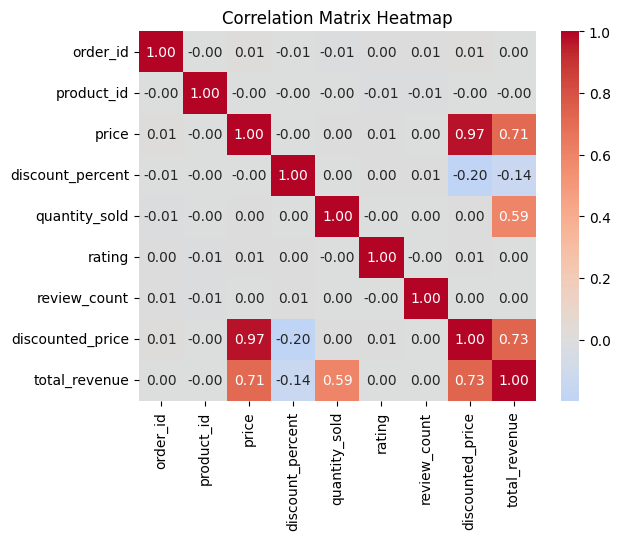

In [76]:
# Visualize the correlation matrix as a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()



Interpretation:

 - Values close to 1 (dark red) = strong positive correlation (both increase together)
 - Values close to -1 (dark blue) = strong negative correlation (one increases, other decreases)
 - Values close to 0 (white) = little or no linear relationship
 - The diagonal is always 1 (each variable correlates perfectly with itself)

From this heatmap, we can see that **price** and **discounted_price** show strong positive correlation (~0.97). Which is what should be expected since discounted price is derived from the original price.

We could also see that **discounted_price** has a strong positive correlation with **total_revenue** (~0.73), which makes sense since higher discounted prices would generally lead to higher revenue.

## 8. Make Plots

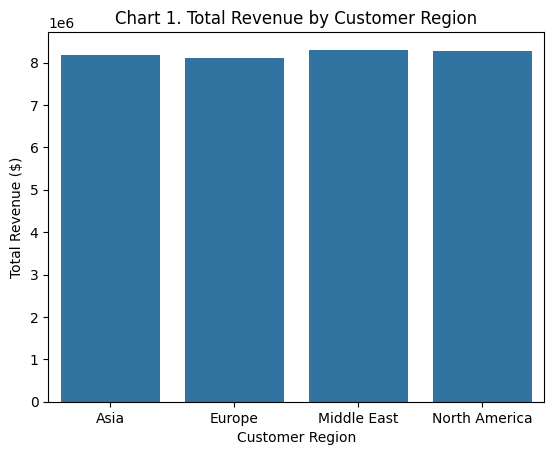

In [77]:
# Create a bar chart plot of total_revenue by customer_region

region_totals: pd.DataFrame = sales_df.groupby("customer_region", as_index=False)["total_revenue"].sum()

bar_plt: Axes = sns.barplot(data=region_totals, x="customer_region", y="total_revenue")

bar_plt.set_xlabel("Customer Region")
bar_plt.set_ylabel("Total Revenue ($)")

bar_plt.set_title("Chart 1. Total Revenue by Customer Region")

plt.show()

### Interpretation of chart 1:
We can observe that all customer regions are spending roughly the same amount of money, around $8 million in 2022 and 2023.

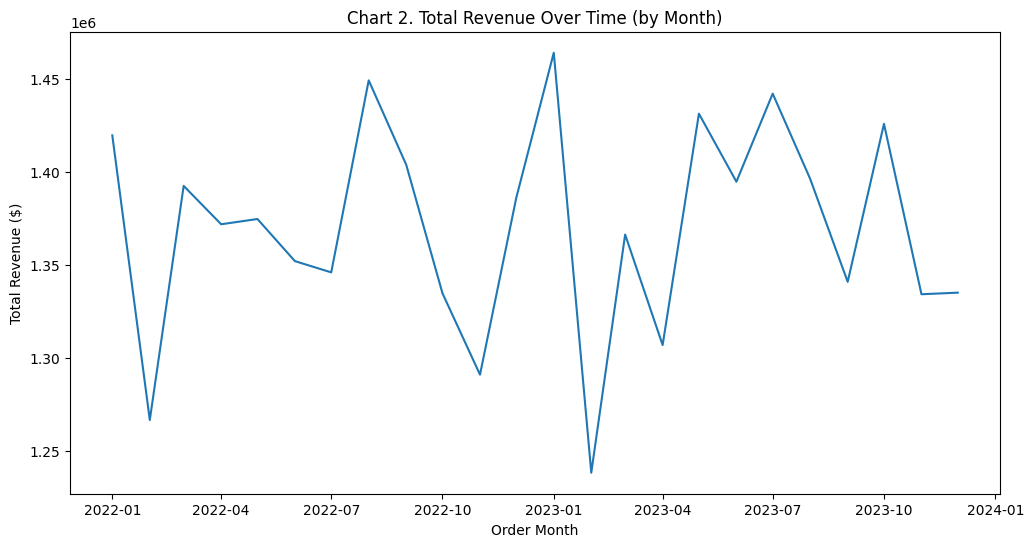

In [78]:
# line plot for total_revenue over time (by order_date) by month

# Convert order_date to datetime and extract month-year for grouping
sales_df["order_date"] = pd.to_datetime(sales_df["order_date"]) 
sales_df["order_month"] = sales_df["order_date"].dt.to_period("M").dt.to_timestamp()

# Group by order_month and sum total_revenue
monthly_revenue: pd.DataFrame = sales_df.groupby("order_month", as_index=False)["total_revenue"].sum()

#make plot bigger
plt.figure(figsize=(12, 6))

# Create a line plot of total_revenue over time (by month)
line_plt: Axes = sns.lineplot(data=monthly_revenue, x="order_month", y="total_revenue")

# Set axis labels and title
line_plt.set_xlabel("Order Month")
line_plt.set_ylabel("Total Revenue ($)")
line_plt.set_title("Chart 2. Total Revenue Over Time (by Month)")



plt.show()

### Interpretation of chart 2:
We can observe that sales are highest in the month of December, which is expected due to the holiday season and increased consumer spending during that time. The lowest sales occur in January and February, which may be attributed to post-holiday spending slowdowns. Overall, there is a clear seasonal trend in sales, with a significant spike towards the end of the year.

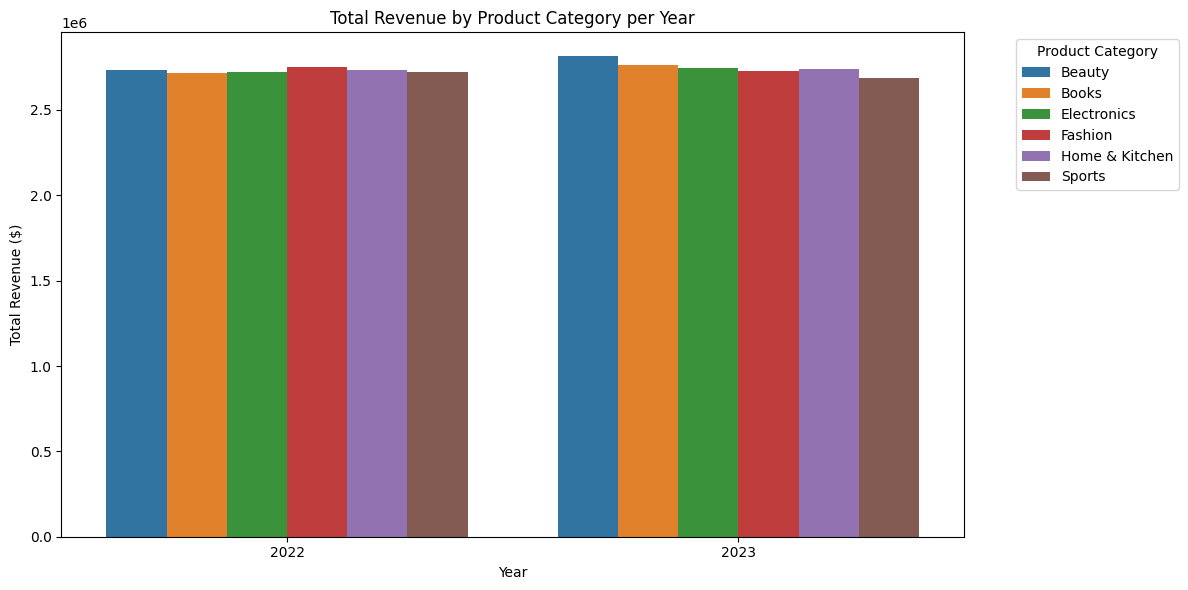

In [79]:
# Ensure order_date is datetime and extract year
sales_df["order_date"] = pd.to_datetime(sales_df["order_date"])
sales_df["order_year"] = sales_df["order_date"].dt.year

# Aggregate total revenue by category and year
category_year = sales_df.groupby(["order_year", "product_category"], as_index=False)["total_revenue"].sum()

plt.figure(figsize=(12,6))
sns.barplot(data=category_year, x="order_year", y="total_revenue", hue="product_category")
plt.xlabel("Year")
plt.ylabel("Total Revenue ($)")
plt.title("Total Revenue by Product Category per Year")
plt.legend(title="Product Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Interpretation of chart 3:
We can see that the Fashion category was the most sold category in 2022, while the Beauty category was the most sold category in 2023.